In [1]:
import torch
import torchvision
print(torch.__version__)
print(torch.cuda.is_available())

1.10.2+cpu
False


In [2]:
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

device = torch.device("cpu")
print("使用设备:", device)

PyTorch: 1.10.2+cpu
CUDA: False
使用设备: cpu


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_set = datasets.CIFAR10(root='./data', train=True,
                              download=True, transform=transform)
test_set = datasets.CIFAR10(root='./data', train=False,
                             download=True, transform=transform)

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False)

print("训练集:", len(train_set))
print("测试集:", len(test_set))

Files already downloaded and verified
Files already downloaded and verified
训练集: 50000
测试集: 10000


In [4]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 10)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))  # 32x32 -> 16x16
        x = self.pool(self.relu(self.conv2(x)))  # 16x16 -> 8x8
        x = self.pool(self.relu(self.conv3(x)))  # 8x8 -> 4x4
        x = x.view(-1, 128 * 4 * 4)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

model = SimpleCNN().to(device)
print(model)

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2048, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
)


In [5]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("损失函数和优化器定义完成")

损失函数和优化器定义完成


In [6]:
import time

epochs = 10
train_losses = []
train_accs = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    start = time.time()
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)
    
    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Loss: {epoch_loss:.4f} "
          f"Acc: {epoch_acc:.2f}% "
          f"Time: {time.time()-start:.1f}s")

Epoch [1/10] Loss: 1.4545 Acc: 46.91% Time: 46.0s
Epoch [2/10] Loss: 1.0417 Acc: 63.16% Time: 45.7s
Epoch [3/10] Loss: 0.8599 Acc: 69.84% Time: 46.0s
Epoch [4/10] Loss: 0.7406 Acc: 74.16% Time: 46.1s
Epoch [5/10] Loss: 0.6426 Acc: 77.26% Time: 46.0s
Epoch [6/10] Loss: 0.5694 Acc: 79.99% Time: 51.4s
Epoch [7/10] Loss: 0.5102 Acc: 81.96% Time: 46.0s
Epoch [8/10] Loss: 0.4509 Acc: 84.03% Time: 45.8s
Epoch [9/10] Loss: 0.3973 Acc: 85.71% Time: 46.2s
Epoch [10/10] Loss: 0.3491 Acc: 87.31% Time: 48.4s


In [7]:
model.eval()
correct = 0
total = 0
test_loss = 0.0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

test_acc = 100. * correct / total
test_loss = test_loss / len(test_loader)

print(f"测试集 Loss: {test_loss:.4f}")
print(f"测试集准确率: {test_acc:.2f}%")

测试集 Loss: 0.7982
测试集准确率: 75.37%


In [8]:
from sklearn.metrics import confusion_matrix
import numpy as np

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

classes = ['plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

print("混淆矩阵（行=真实，列=预测）：")
print(cm)

混淆矩阵（行=真实，列=预测）：
[[786  20  62  14  21   2  15   5  43  32]
 [  8 889  11   8   2   3   9   3  21  46]
 [ 47   3 707  31  76  36  66  20  10   4]
 [ 17  15  95 481  74 171  92  27  13  15]
 [ 15   2  86  34 768  19  47  19   8   2]
 [  9   5  73 131  58 656  25  33   4   6]
 [  1   5  47  32  23   9 869   3  10   1]
 [ 16   3  51  28  92  47   4 747   2  10]
 [ 61  23  22   7   6   4   9   7 846  15]
 [ 37 103   8   6   5   8  17   9  19 788]]


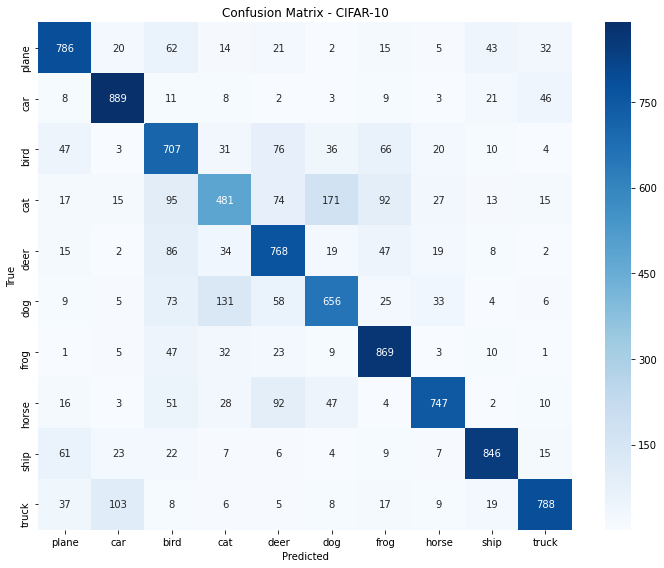

In [9]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - CIFAR-10')
plt.tight_layout()
plt.show()

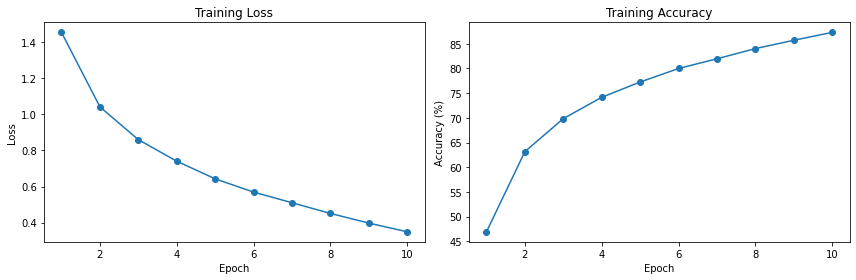

In [10]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, 11), train_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')

plt.subplot(1, 2, 2)
plt.plot(range(1, 11), train_accs, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training Accuracy')

plt.tight_layout()
plt.show()